In [56]:
# ── Clustering notebook — load EDA handoff ──────────────────────────────────
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

with open('eda_handoff.pkl', 'rb') as _f:
    _h = pickle.load(_f)

df_units       = _h['df_units']
df_used_market = _h['df_used_market']
name_map       = _h['name_map']

print('Handoff loaded.')
print(f'  df_units       {df_units.shape}')
print(f'  df_used_market {df_used_market.shape}')
print(f'  name_map keys  {len(name_map)}')


Handoff loaded.
  df_units       (8599, 38)
  df_used_market (10239, 37)
  name_map keys  4234


Kmeans and segmentation

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Ensure 'ANO' column is numeric before feature engineering
df_units['ANO'] = df_units['ANO'].astype(int)

# 1. Feature Engineering
segmentation_data = df_units.groupby('RUC IMPORTADOR').agg({
    'US$ FOB': 'sum',
    'PARTIDA_CLEAN': 'nunique',
    'ANO': [lambda x: x.max() - x.min(), 'count']
})

segmentation_data.columns = ['Total_Spend', 'Product_Variety', 'Years_Active', 'Transaction_Count']

# 2. Scaling the data (Crucial for K-Means!)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(segmentation_data)

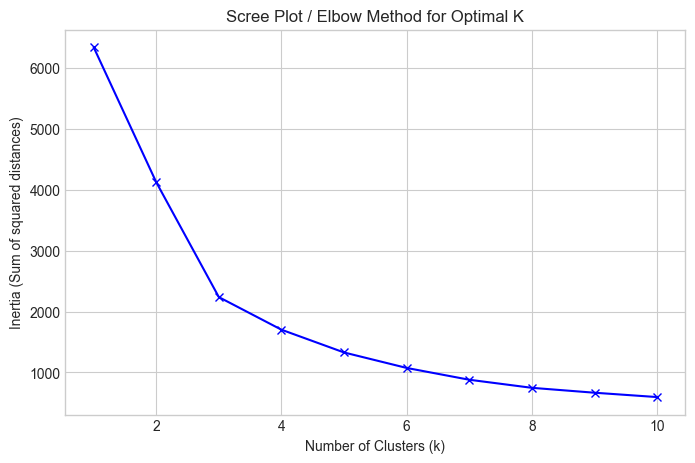

In [58]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.title('Scree Plot / Elbow Method for Optimal K')
plt.show()

In [59]:
# ok, so three it seems
# 1. Fit the model with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
segmentation_data['Cluster'] = kmeans.fit_predict(scaled_features)

# 2. Characterize the Clusters (The "Centroids")
# This tells us the average behavior of each group
cluster_profiles = segmentation_data.groupby('Cluster').mean()

# Add a count to see how many importers are in each group
cluster_profiles['Importers_Count'] = segmentation_data['Cluster'].value_counts()

print("--- Cluster Profiles (Averages) ---")
display(cluster_profiles)

--- Cluster Profiles (Averages) ---


,Total_Spend,Product_Variety,Years_Active,Transaction_Count,Importers_Count
Cluster,,,,,
0,"1,371,075.70",2.69,6.26,20.15,212
1,"112,547.39",1.18,0.36,2.01,1371
2,"39,503,977.63",6.00,7.67,526.00,3


In [60]:
# ok, so now we'll try with 10 clusters
# 1. Fit the model with k=10
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
segmentation_data['Cluster'] = kmeans.fit_predict(scaled_features)

# 2. Characterize the Clusters (The "Centroids")
# This tells us the average behavior of each group
cluster_profiles = segmentation_data.groupby('Cluster').mean()

# Add a count to see how many importers are in each group
cluster_profiles['Importers_Count'] = segmentation_data['Cluster'].value_counts()

print("--- Cluster Profiles (Averages) ---")
display(cluster_profiles)

--- Cluster Profiles (Averages) ---


,Total_Spend,Product_Variety,Years_Active,Transaction_Count,Importers_Count
Cluster,,,,,
0,"429,827.05",1.74,4.39,6.82,137
1,"79,894.82",1.00,0.14,1.49,1117
2,"29,056,890.91",8.00,4.00,561.00,1
3,"6,914,076.28",7.33,8.00,113.00,6
4,"1,316,034.93",4.30,5.32,21.86,37
5,"51,342,940.90",4.00,11.00,837.00,1
6,"38,112,101.08",6.00,8.00,180.00,1
7,"9,134,175.86",3.33,9.22,118.22,9
8,"1,005,226.18",2.16,8.37,14.37,68


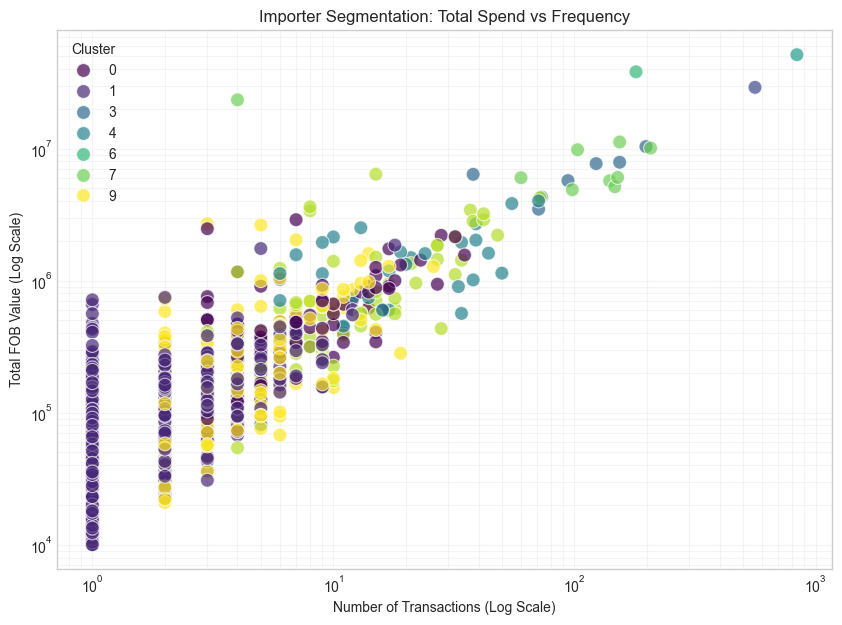

In [61]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=segmentation_data,
    x='Transaction_Count',
    y='Total_Spend',
    hue='Cluster',
    palette='viridis',
    s=100, alpha=0.7
)

# Using log scale if the 'Whales' are pushing everyone else to the corner
plt.yscale('log')
plt.xscale('log')

plt.title('Importer Segmentation: Total Spend vs Frequency')
plt.xlabel('Number of Transactions (Log Scale)')
plt.ylabel('Total FOB Value (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [62]:
# Change the cluster number based on which one has the 'Middle' stats in your profiles
target_cluster = (cluster_profiles['Total_Spend'] - cluster_profiles['Total_Spend'].median()).abs().idxmin()

leads = segmentation_data[segmentation_data['Cluster'] == target_cluster].sort_values('Total_Spend', ascending=False)

print(f"--- Top Leads in Cluster {target_cluster} (The Target Segment) ---")
display(leads.head(10))

--- Top Leads in Cluster 3 (The Target Segment) ---


,Total_Spend,Product_Variety,Years_Active,Transaction_Count,Cluster
RUC IMPORTADOR,,,,,
20517931536,"10,347,040.79",8,11,198,3
20606433469,"7,876,555.80",6,6,154,3
20601770815,"7,689,277.56",7,9,123,3
20546301312,"6,379,835.49",7,4,38,3
20490425668,"5,719,062.23",8,11,94,3
20602250866,"3,472,685.80",8,7,71,3


In [63]:
#import sys
#!{sys.executable} -m pip install pyclustering

In [64]:
#pip install --upgrade s-dbw

In [65]:
# validation metrics
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np

sdbw_available = False
try:
    from s_dbw import S_Dbw
    sdbw_available = True
except ImportError:
    print("Warning: s_dbw not found. S_Dbw index will be skipped.")

results = []
for k in [3, 4, 7, 10]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)

    sil = silhouette_score(scaled_features, labels)
    cal = calinski_harabasz_score(scaled_features, labels)
    dav = davies_bouldin_score(scaled_features, labels)

    sdbw = None
    if sdbw_available:
        try:
            sdbw = S_Dbw(scaled_features, labels)
        except Exception as e:
            print(f"Error calculating S_Dbw for k={k}: {e}")

    results.append({'k': k, 'Silhouette': sil, 'Calinski': cal, 'Davies-Bouldin': dav, 'S_Dbw': sdbw})

validation_df = pd.DataFrame(results)
print(validation_df)

    k  Silhouette  Calinski  Davies-Bouldin  S_Dbw
0   3        0.74  1,453.10            0.67   3.22
1   4        0.73  1,439.12            0.80   2.68
2   7        0.74  1,635.34            0.77   1.21
3  10        0.75  1,692.57            0.71   0.58


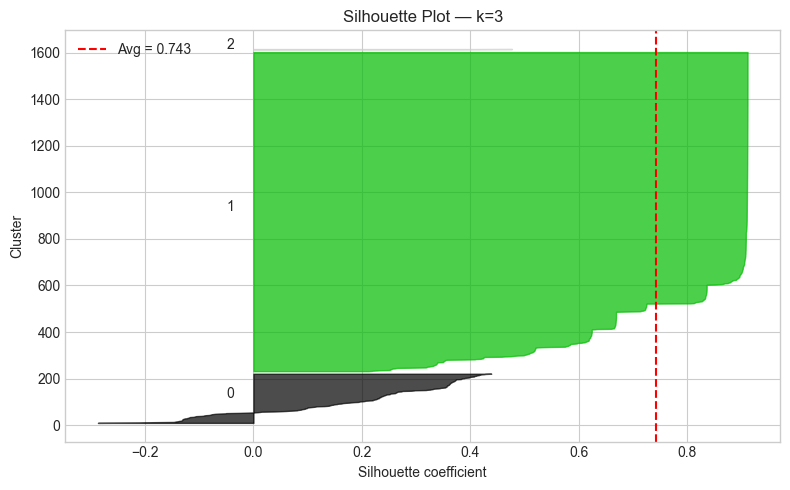

k=3  →  Avg silhouette score: 0.7434


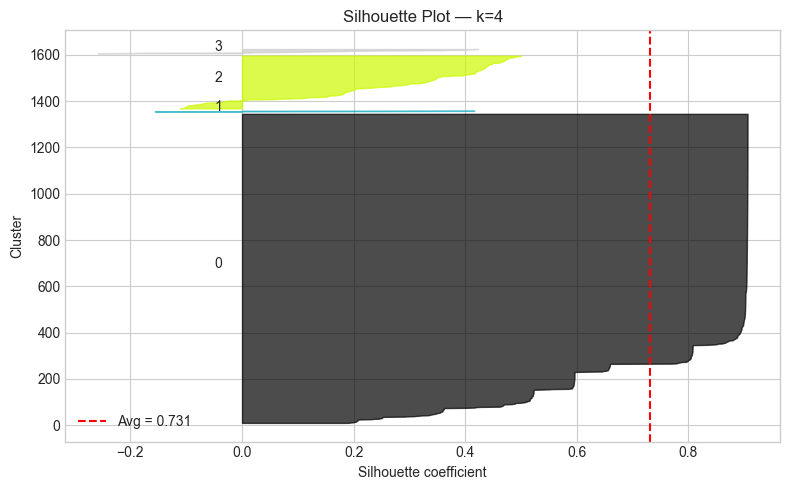

k=4  →  Avg silhouette score: 0.7308


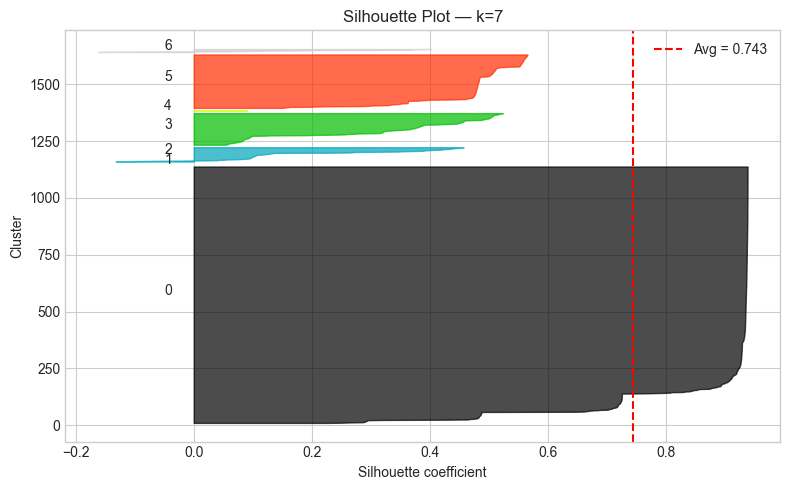

k=7  →  Avg silhouette score: 0.7433


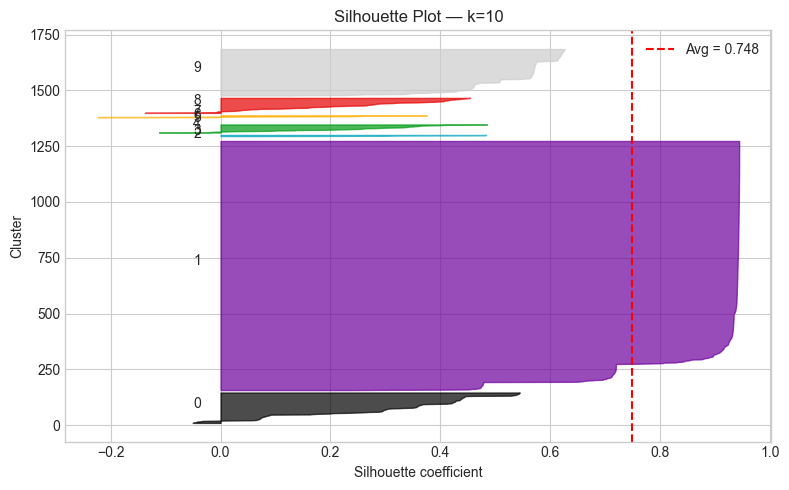

k=10  →  Avg silhouette score: 0.7484


In [66]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

for k in [3, 4, 7, 10]:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(scaled_features)
    sil_avg = silhouette_score(scaled_features, labels)
    sil_vals = silhouette_samples(scaled_features, labels)

    fig, ax = plt.subplots(figsize=(8, 5))
    y_lower = 10
    colors = cm.nipy_spectral(np.linspace(0, 1, k))
    for cluster_i in range(k):
        cluster_sil = np.sort(sil_vals[labels == cluster_i])
        y_upper = y_lower + len(cluster_sil)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                          facecolor=colors[cluster_i], edgecolor=colors[cluster_i], alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * len(cluster_sil), str(cluster_i))
        y_lower = y_upper + 10
    ax.axvline(sil_avg, color="red", linestyle="--", label=f"Avg = {sil_avg:.3f}")
    ax.set_title(f"Silhouette Plot — k={k}")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"k={k}  →  Avg silhouette score: {sil_avg:.4f}")


NOW LET'S CHECK OTHER ADVANCED CLUSTERING ALGORITHMS

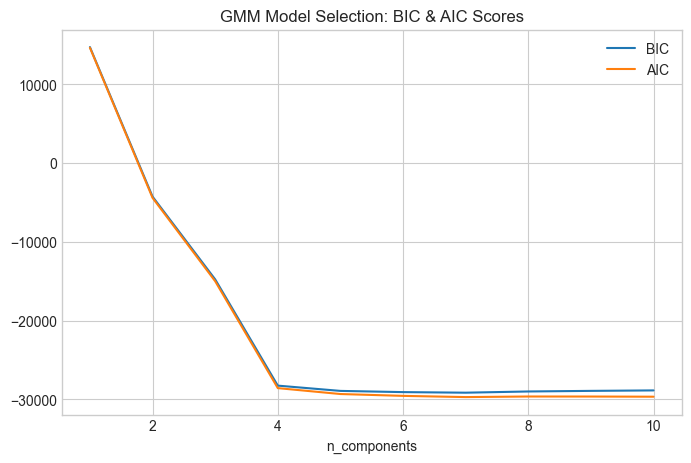


--- Running GMM with 7 components  ---
GMM Soft Clustering Complete for k=7.


,Total_Spend,Product_Variety,Years_Active,Transaction_Count,Cluster,GMM_Cluster_7,Prob_Cluster_7_0,Prob_Cluster_7_1,Prob_Cluster_7_2,Prob_Cluster_7_3,Prob_Cluster_7_4,Prob_Cluster_7_5,Prob_Cluster_7_6
RUC IMPORTADOR,,,,,,,,,,,,,
0,"29,056,890.91",8,4,561,2,2,0.00,0.00,1.00,0.00,0.00,0.00,0.00
10000766742,"36,672.00",1,0,1,1,1,0.00,1.00,0.00,0.00,0.00,0.00,0.00
10005171810,"101,678.96",2,3,3,0,0,0.96,0.00,0.00,0.00,0.00,0.01,0.02
10013095812,"1,945,272.78",4,2,34,4,3,0.00,0.00,0.00,0.99,0.01,0.00,0.00
10013263677,"127,166.00",2,3,4,0,0,0.98,0.00,0.00,0.00,0.00,0.00,0.02


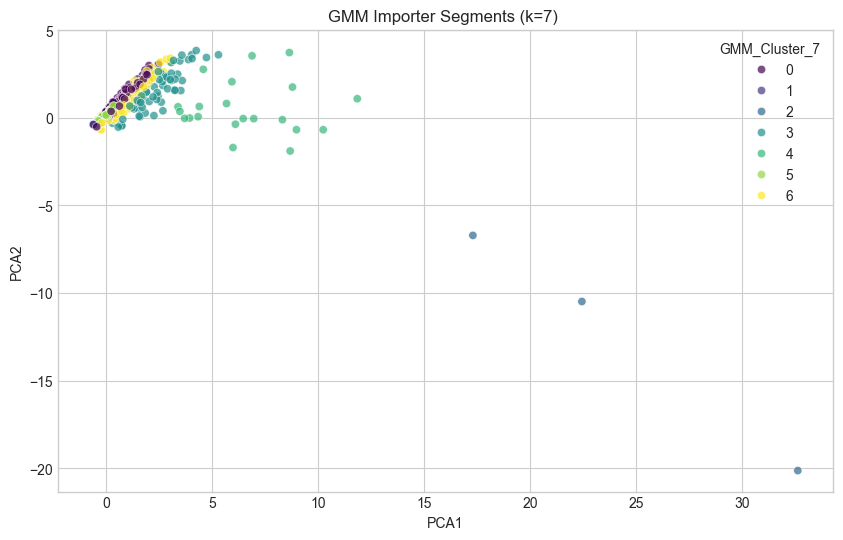


--- Testing GMM Stability with Poisson Noise ---

--- Running GMM with 7 components with Poisson Noise ---
GMM Soft Clustering Complete for k=7with Poisson Noise.


,Total_Spend,Product_Variety,Years_Active,Transaction_Count,Cluster,GMM_Cluster_7,Prob_Cluster_7_0,Prob_Cluster_7_1,Prob_Cluster_7_2,Prob_Cluster_7_3,Prob_Cluster_7_4,Prob_Cluster_7_5,Prob_Cluster_7_6
RUC IMPORTADOR,,,,,,,,,,,,,
0,"29,056,890.91",8,4,561,2,2,0.00,0.00,1.00,0.00,0.00,0.00,0.00
10000766742,"36,672.00",1,0,1,1,1,0.00,0.99,0.00,0.00,0.01,0.00,0.00
10005171810,"101,678.96",2,3,3,0,0,0.91,0.00,0.00,0.00,0.09,0.00,0.01
10013095812,"1,945,272.78",4,2,34,4,6,0.00,0.00,0.00,0.01,0.00,0.00,0.99
10013263677,"127,166.00",2,3,4,0,0,0.91,0.00,0.00,0.00,0.08,0.00,0.01


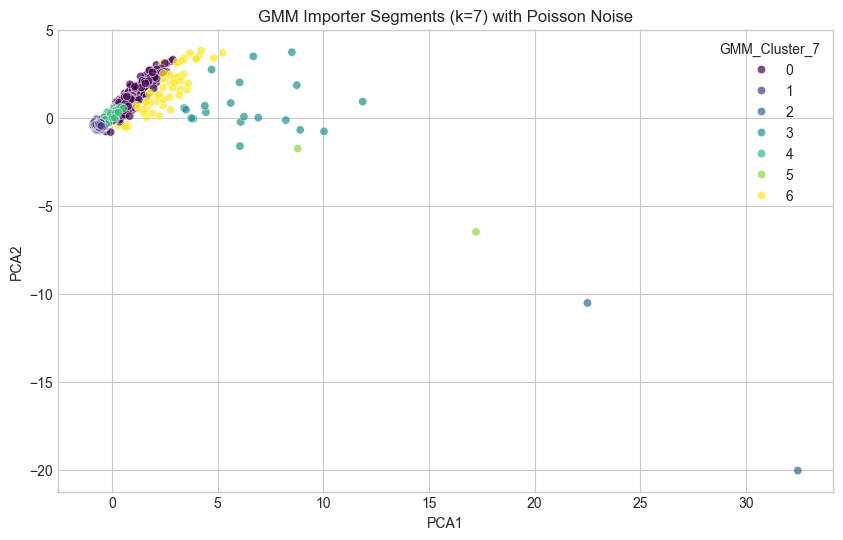

In [67]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Assuming `scaled_features` and `segmentation_data` are already defined
# from previous cells in the notebook.

# 1. Finding the optimal number of components using BIC/AIC (initial run)
# Lower BIC = Better Model
n_components_range = np.arange(1, 11)
models = [GaussianMixture(n, covariance_type='full', random_state=42).fit(scaled_features)
          for n in n_components_range]

plt.figure(figsize=(8, 5))
plt.plot(n_components_range, [m.bic(scaled_features) for m in models], label='BIC')
plt.plot(n_components_range, [m.aic(scaled_features) for m in models], label='AIC')
plt.legend(loc='best')
plt.xlabel('n_components')
plt.title('GMM Model Selection: BIC & AIC Scores')
plt.show()

def run_gmm_and_plot(data_to_cluster, n_components, segmentation_df, title_suffix=""):
    """Fits GMM, predicts labels, adds to DataFrame, and plots first two principal components."""
    print(f"\n--- Running GMM with {n_components} components {title_suffix} ---")
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
    gmm_labels = gmm.fit_predict(data_to_cluster)
    probs = gmm.predict_proba(data_to_cluster)

    # Add labels and probabilities to a copy of the segmentation data to avoid modifying original
    seg_data_copy = segmentation_df.copy()
    seg_data_copy[f'GMM_Cluster_{n_components}'] = gmm_labels
    for i in range(n_components):
        seg_data_copy[f'Prob_Cluster_{n_components}_{i}'] = probs[:, i]

    print(f"GMM Soft Clustering Complete for k={n_components}{title_suffix}.")
    display(seg_data_copy.head())

    # PCA for 2D Visualization (re-using existing PCA setup if possible, or re-calculating)
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    pca_components = pca.fit_transform(data_to_cluster)
    seg_data_copy['PCA1'] = pca_components[:, 0]
    seg_data_copy['PCA2'] = pca_components[:, 1]

    plt.figure(figsize=(10, 6))
    import seaborn as sns
    sns.scatterplot(data=seg_data_copy, x='PCA1', y='PCA2', hue=f'GMM_Cluster_{n_components}', palette='viridis', alpha=0.7)
    plt.title(f'GMM Importer Segments (k={n_components}) {title_suffix}')
    plt.show()
    return seg_data_copy


# 2. Run GMM for k=3, 7, and 10 as requested by the user
# segmentation_data_k3 = run_gmm_and_plot(scaled_features, 3, segmentation_data)
segmentation_data_k7 = run_gmm_and_plot(scaled_features, 7, segmentation_data)
# segmentation_data_k10 = run_gmm_and_plot(scaled_features, 10, segmentation_data)

# 3. Introduce Poisson Noise to test stability
print("\n--- Testing GMM Stability with Poisson Noise ---")
np.random.seed(42) # for reproducibility
# Adding a small amount of Poisson noise (ensure non-negative data for Poisson)
# As scaled features can be negative, we'll add noise in a way that doesn't drastically alter scale
# A common approach for this is to add noise to the *original* (or normalized 0-1) data and then re-scale.
# For simplicity here, let's add a small, uniformly scaled random component to `scaled_features`

# Create a noisy version of scaled_features
noise_scale = 0.1 # Adjust this to control the amount of noise
noisy_scaled_features = scaled_features + np.random.normal(0, noise_scale, scaled_features.shape)

# Re-scale the noisy features (important after adding noise)
scaler_noisy = StandardScaler()
rescaled_noisy_features = scaler_noisy.fit_transform(noisy_scaled_features)

# 4. Re-run GMM for k=3 and k=7 with noisy data
# segmentation_data_noisy_k3 = run_gmm_and_plot(rescaled_noisy_features, 3, segmentation_data, title_suffix="with Poisson Noise")
segmentation_data_noisy_k7 = run_gmm_and_plot(rescaled_noisy_features, 7, segmentation_data, title_suffix="with Poisson Noise")

In [68]:
from sklearn.metrics import silhouette_score

# Assuming segmentation_data_k7 was the output of run_gmm_and_plot for k=7
# and contains the 'GMM_Cluster_7' column.
# Also assuming scaled_features is still available from previous cells.

# Get the GMM labels for k=7 from the dataframe produced by the run_gmm_and_plot function
k7_labels = segmentation_data_k7['GMM_Cluster_7']

# Calculate the silhouette score
silhouette_avg_k7 = silhouette_score(scaled_features, k7_labels)

print(f"Silhouette Score for GMM (k=7): {silhouette_avg_k7:.4f}")

Silhouette Score for GMM (k=7): 0.5536


### Comparison of GMM Cluster Centroids (k=7) - Original vs. Noisy Data

In [69]:
print("--- Original GMM (k=7) Cluster Profiles (Averages) ---")
original_gmm_profiles = segmentation_data_k7.groupby('GMM_Cluster_7')[['Total_Spend', 'Product_Variety', 'Years_Active', 'Transaction_Count']].mean()
display(original_gmm_profiles)

print("\n--- Noisy GMM (k=7) Cluster Profiles (Averages) ---")
noisy_gmm_profiles = segmentation_data_noisy_k7.groupby('GMM_Cluster_7')[['Total_Spend', 'Product_Variety', 'Years_Active', 'Transaction_Count']].mean()
display(noisy_gmm_profiles)

--- Original GMM (k=7) Cluster Profiles (Averages) ---


,Total_Spend,Product_Variety,Years_Active,Transaction_Count
GMM_Cluster_7,,,,
0,"219,968.50",1.80,3.22,4.23
1,"58,619.44",1.00,0.00,1.17
2,"39,503,977.63",6.00,7.67,526.00
3,"1,636,976.27",2.98,5.53,20.61
4,"7,050,749.47",4.52,7.81,98.67
5,"108,028.67",1.63,0.78,2.64
6,"563,000.35",1.89,4.33,9.10



--- Noisy GMM (k=7) Cluster Profiles (Averages) ---


,Total_Spend,Product_Variety,Years_Active,Transaction_Count
GMM_Cluster_7,,,,
0,"392,273.54",1.90,4.91,6.71
1,"66,839.29",1.00,0.01,1.26
2,"40,199,915.91",6.00,7.50,699.00
3,"6,234,511.79",4.60,7.70,103.40
4,"151,739.76",1.67,0.92,3.29
5,"30,743,802.04",4.50,9.00,92.00
6,"1,479,625.91",3.14,5.47,19.21



--- Running GMM with 3 components  ---
GMM Soft Clustering Complete for k=3.


,Total_Spend,Product_Variety,Years_Active,Transaction_Count,Cluster,GMM_Cluster_3,Prob_Cluster_3_0,Prob_Cluster_3_1,Prob_Cluster_3_2
RUC IMPORTADOR,,,,,,,,,
0,"29,056,890.91",8,4,561,2,2,0.00,0.00,1.00
10000766742,"36,672.00",1,0,1,1,1,0.00,1.00,0.00
10005171810,"101,678.96",2,3,3,0,0,1.00,0.00,0.00
10013095812,"1,945,272.78",4,2,34,4,0,1.00,0.00,0.00
10013263677,"127,166.00",2,3,4,0,0,1.00,0.00,0.00


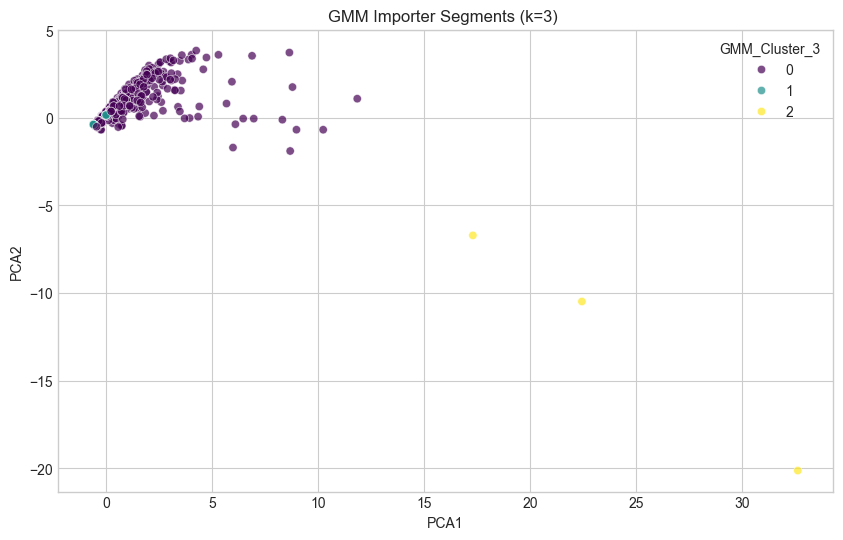


--- Running GMM with 10 components  ---
GMM Soft Clustering Complete for k=10.


,Total_Spend,Product_Variety,Years_Active,Transaction_Count,Cluster,GMM_Cluster_10,Prob_Cluster_10_0,Prob_Cluster_10_1,Prob_Cluster_10_2,Prob_Cluster_10_3,Prob_Cluster_10_4,Prob_Cluster_10_5,Prob_Cluster_10_6,Prob_Cluster_10_7,Prob_Cluster_10_8,Prob_Cluster_10_9
RUC IMPORTADOR,,,,,,,,,,,,,,,,
0,"29,056,890.91",8,4,561,2,2,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
10000766742,"36,672.00",1,0,1,1,1,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
10005171810,"101,678.96",2,3,3,0,0,0.91,0.00,0.00,0.00,0.00,0.00,0.08,0.01,0.00,0.00
10013095812,"1,945,272.78",4,2,34,4,7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.99,0.00,0.01
10013263677,"127,166.00",2,3,4,0,0,0.97,0.00,0.00,0.00,0.00,0.00,0.03,0.01,0.00,0.00


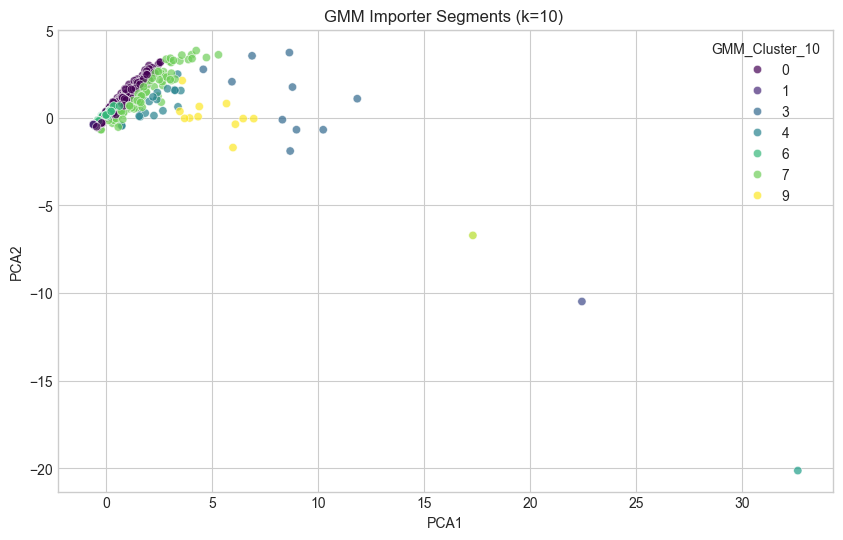


--- Running GMM with 3 components with Poisson Noise ---
GMM Soft Clustering Complete for k=3with Poisson Noise.


,Total_Spend,Product_Variety,Years_Active,Transaction_Count,Cluster,GMM_Cluster_3,Prob_Cluster_3_0,Prob_Cluster_3_1,Prob_Cluster_3_2
RUC IMPORTADOR,,,,,,,,,
0,"29,056,890.91",8,4,561,2,2,0.00,0.00,1.00
10000766742,"36,672.00",1,0,1,1,1,0.00,1.00,0.00
10005171810,"101,678.96",2,3,3,0,0,1.00,0.00,0.00
10013095812,"1,945,272.78",4,2,34,4,0,1.00,0.00,0.00
10013263677,"127,166.00",2,3,4,0,0,1.00,0.00,0.00


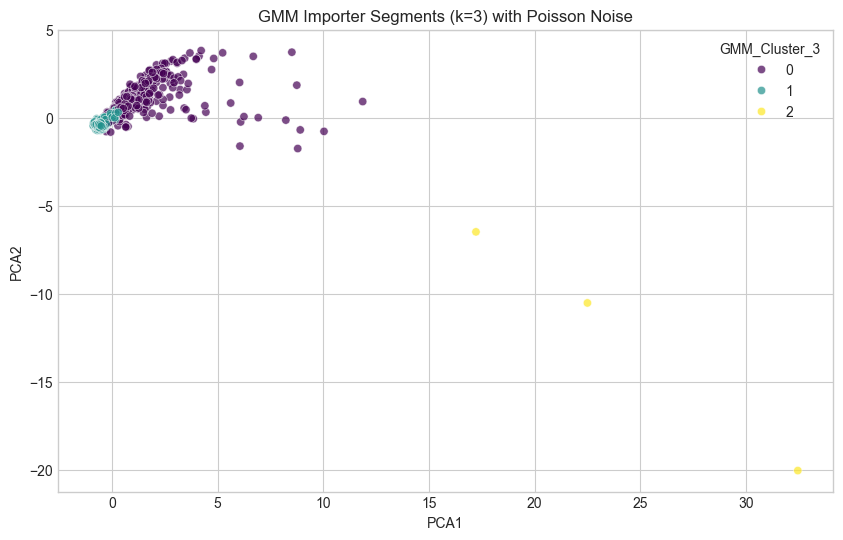

In [70]:
# 2. Run GMM for k=3 and k=10
segmentation_data_k3 = run_gmm_and_plot(scaled_features, 3, segmentation_data)
segmentation_data_k10 = run_gmm_and_plot(scaled_features, 10, segmentation_data)

# 4. Re-run GMM for k=3 with noisy data
segmentation_data_noisy_k3 = run_gmm_and_plot(rescaled_noisy_features, 3, segmentation_data, title_suffix="with Poisson Noise")

Comparing these two sets of cluster profiles allows us to assess the stability of the GMM clustering. If the profiles are similar, it suggests the clusters are robust to the introduced noise. Significant differences might indicate that the clusters are sensitive to small perturbations in the data.

In [71]:
# ── Validation Metrics: Silhouette, CH, Davies-Bouldin, S_Dbw, PWI ──────────
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans
import numpy as np

# ── S_Dbw ────────────────────────────────────────────────────────────────────
try:
    from s_dbw import S_Dbw
    sdbw_available = True
except ImportError:
    print("Warning: s_dbw not installed. S_Dbw will be skipped.")
    sdbw_available = False

# ── PWI helper ───────────────────────────────────────────────────────────────
def compute_pwi(k_values, silhouette_scores, calinski_scores, epsilon=1):
    """
    Peak Weight Index — Wang & Xu (IOP Conf. Ser. Mater. Sci. Eng. 569, 2019).

    Combines Silhouette (S) and Calinski-Harabasz (CH) into a single score.
    Both indices are min-max normalised to [0, 1] so they contribute equally.
    Local peaks (strict local maxima) receive double weight in the sliding
    window of width 2ε+1 to reduce sensitivity to random fluctuations.
    Optimal k = argmax(PWI).  Higher value = better clustering.

    Note: The paper under-specifies the exact weight-assignment rules;
    this implementation follows the stated formula and spirit of the algorithm.
    """
    s  = np.array(silhouette_scores, dtype=float)
    ch = np.array(calinski_scores,   dtype=float)
    n  = len(k_values)

    # Min-max normalise both to [0, 1]
    def minmax(arr):
        rng = arr.max() - arr.min()
        return (arr - arr.min()) / (rng if rng > 0 else 1.0)

    s_norm  = minmax(s)
    ch_norm = minmax(ch)   # paper explicitly requires this for CH

    # Weight = 2 at strict local maxima, 1 elsewhere
    def peak_weights(arr):
        w = np.ones(n)
        for i in range(n):
            is_left_peak  = (i == 0)   or (arr[i] > arr[i - 1])
            is_right_peak = (i == n-1) or (arr[i] > arr[i + 1])
            if is_left_peak and is_right_peak:
                w[i] = 2.0
        return w

    ws = peak_weights(s_norm)
    wc = peak_weights(ch_norm)

    pwi = np.zeros(n)
    for idx in range(n):
        lo = max(0, idx - epsilon)
        hi = min(n - 1, idx + epsilon)
        pws = np.average(s_norm[lo:hi+1],  weights=ws[lo:hi+1])
        pwc = np.average(ch_norm[lo:hi+1], weights=wc[lo:hi+1])
        pwi[idx] = (pws + pwc) / 2.0

    return pwi

# ── Per-k metrics ─────────────────────────────────────────────────────────────
k_range = [3, 4, 7, 10]
results = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)

    sil = silhouette_score(scaled_features, labels)
    cal = calinski_harabasz_score(scaled_features, labels)
    dav = davies_bouldin_score(scaled_features, labels)

    sdbw = None
    if sdbw_available:
        try:
            sdbw = S_Dbw(scaled_features, labels)
        except Exception as e:
            print(f"S_Dbw error at k={k}: {e}")

    results.append({'k': k, 'Silhouette ↑': sil, 'Calinski ↑': cal,
                    'Davies-Bouldin ↓': dav, 'S_Dbw ↓': sdbw})

validation_df = pd.DataFrame(results).set_index('k')

# ── PWI (requires all k values at once) ──────────────────────────────────────
sil_vals = [r['Silhouette ↑']    for r in results]
cal_vals = [r['Calinski ↑']      for r in results]
pwi_vals = compute_pwi(k_range, sil_vals, cal_vals)
validation_df['PWI ↑'] = pwi_vals

print(validation_df.round(4))
print(f"\n→ Best k by Silhouette  : k={k_range[np.argmax(sil_vals)]}")
print(f"→ Best k by Calinski    : k={k_range[np.argmax(cal_vals)]}")
print(f"→ Best k by Davies-Bouldin: k={k_range[np.argmin([r['Davies-Bouldin ↓'] for r in results])]}")
if sdbw_available:
    sdbw_vals = [r['S_Dbw ↓'] for r in results if r['S_Dbw ↓'] is not None]
    if sdbw_vals:
        print(f"→ Best k by S_Dbw       : k={k_range[np.argmin([r['S_Dbw ↓'] for r in results])]}")
print(f"→ Best k by PWI         : k={k_range[np.argmax(pwi_vals)]}")

    Silhouette ↑  Calinski ↑  Davies-Bouldin ↓  S_Dbw ↓  PWI ↑
k                                                             
3           0.74    1,453.10              0.67     3.22   0.26
4           0.73    1,439.12              0.80     2.68   0.38
7           0.74    1,635.34              0.77     1.21   0.69
10          0.75    1,692.57              0.71     0.58   0.91

→ Best k by Silhouette  : k=10
→ Best k by Calinski    : k=10
→ Best k by Davies-Bouldin: k=3
→ Best k by S_Dbw       : k=10
→ Best k by PWI         : k=10


In [72]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans # Added import
import pandas as pd # Added import
import numpy as np # Added import for S_Dbw

sdbw_available = False
try:
    from s_dbw import S_Dbw
    sdbw_available = True
except ImportError:
    print("Warning: s_dbw not found. S_Dbw index will be skipped.")

# ── PWI helper ────────────────────────────────
def compute_pwi(k_values, silhouette_scores, calinski_scores, epsilon=1):
    """
    Peak Weight Index ─ Wang & Xu (IOP Conf. Ser. Mater. Sci. Eng. 569, 2019).

    Combines Silhouette (S) and Calinski-Harabasz (CH) into a single score.
    Both indices are min-max normalised to [0, 1] so they contribute equally.
    Local peaks (strict local maxima) receive double weight in the sliding
    window of width 2ε+1 to reduce sensitivity to random fluctuations.
    Optimal k = argmax(PWI).  Higher value = better clustering.

    Note: The paper under-specifies the exact weight-assignment rules;
    this implementation follows the stated formula and spirit of the algorithm.
    """
    s  = np.array(silhouette_scores, dtype=float)
    ch = np.array(calinski_scores,   dtype=float)
    n  = len(k_values)

    # Min-max normalise both to [0, 1]
    def minmax(arr):
        rng = arr.max() - arr.min()
        return (arr - arr.min()) / (rng if rng > 0 else 1.0)

    s_norm  = minmax(s)
    ch_norm = minmax(ch)

    # Weight = 2 at strict local maxima, 1 elsewhere
    def peak_weights(arr):
        w = np.ones(n)
        for i in range(n):
            is_left_peak  = (i == 0)   or (arr[i] > arr[i - 1])
            is_right_peak = (i == n-1) or (arr[i] > arr[i + 1])
            if is_left_peak and is_right_peak:
                w[i] = 2.0
        return w

    ws = peak_weights(s_norm)
    wc = peak_weights(ch_norm)

    pwi = np.zeros(n)
    for idx in range(n):
        lo = max(0, idx - epsilon)
        hi = min(n - 1, idx + epsilon)
        pws = np.average(s_norm[lo:hi+1],  weights=ws[lo:hi+1])
        pwc = np.average(ch_norm[lo:hi+1], weights=wc[lo:hi+1])
        pwi[idx] = (pws + pwc) / 2.0

    return pwi

# Code to define validation_df (copied from cell KfQn7QixPODy)
results_kmeans = []
k_range = [3, 4, 7, 10]
for k in k_range:
    # Fit model
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)

    # Calculate Metrics
    sil = silhouette_score(scaled_features, labels)
    cal = calinski_harabasz_score(scaled_features, labels)
    dav = davies_bouldin_score(scaled_features, labels)

    sdbw = None
    if sdbw_available:
        try:
            sdbw = S_Dbw(scaled_features, labels)
        except Exception as e:
            print(f"Error calculating S_Dbw for KMeans k={k}: {e}")

    results_kmeans.append({'k': k, 'Silhouette': sil, 'Calinski': cal, 'Davies-Bouldin': dav, 'S_Dbw': sdbw})

validation_df = pd.DataFrame(results_kmeans)

# Calculate PWI for KMeans
sil_vals_kmeans = [r['Silhouette'] for r in results_kmeans]
cal_vals_kmeans = [r['Calinski'] for r in results_kmeans]
pwi_vals_kmeans = compute_pwi(k_range, sil_vals_kmeans, cal_vals_kmeans)

results_summary = []

# Add KMeans results from the existing validation_df
for idx, row in validation_df.iterrows():
    results_summary.append({
        'Algorithm': 'KMeans',
        'k': row['k'],
        'Noise_Status': 'Original',
        'Silhouette': row['Silhouette'],
        'Calinski_Harabasz': row['Calinski'],
        'Davies_Bouldin': row['Davies-Bouldin'],
        'S_Dbw': row['S_Dbw'],
        'PWI': pwi_vals_kmeans[idx]
    })

# --- GMM Metrics Collection ---
all_gmm_original_sils = []
all_gmm_original_cals = []
all_gmm_original_davs = []
all_gmm_original_sdbws = []

all_gmm_noisy_sils = []
all_gmm_noisy_cals = []
all_gmm_noisy_davs = []
all_gmm_noisy_sdbws = []

for k_val_idx, k_val in enumerate(k_range):
    # GMM - Original Data
    gmm_original = GaussianMixture(n_components=k_val, covariance_type='full', random_state=42)
    gmm_original_labels = gmm_original.fit_predict(scaled_features)

    gmm_original_sdbw = None
    if sdbw_available:
        try:
            gmm_original_sdbw = S_Dbw(scaled_features, gmm_original_labels)
        except Exception as e:
            print(f"Error calculating S_Dbw for GMM original k={k_val}: {e}")

    gmm_original_sil = silhouette_score(scaled_features, gmm_original_labels)
    gmm_original_cal = calinski_harabasz_score(scaled_features, gmm_original_labels)
    gmm_original_dav = davies_bouldin_score(scaled_features, gmm_original_labels)

    all_gmm_original_sils.append(gmm_original_sil)
    all_gmm_original_cals.append(gmm_original_cal)
    all_gmm_original_davs.append(gmm_original_dav)
    all_gmm_original_sdbws.append(gmm_original_sdbw)

    # GMM - Noisy Data
    gmm_noisy = GaussianMixture(n_components=k_val, covariance_type='full', random_state=42)
    gmm_noisy_labels = gmm_noisy.fit_predict(rescaled_noisy_features)

    gmm_noisy_sdbw = None
    if sdbw_available:
        try:
            gmm_noisy_sdbw = S_Dbw(rescaled_noisy_features, gmm_noisy_labels)
        except Exception as e:
            print(f"Error calculating S_Dbw for GMM noisy k={k_val}: {e}")

    gmm_noisy_sil = silhouette_score(rescaled_noisy_features, gmm_noisy_labels)
    gmm_noisy_cal = calinski_harabasz_score(rescaled_noisy_features, gmm_noisy_labels)
    gmm_noisy_dav = davies_bouldin_score(rescaled_noisy_features, gmm_noisy_labels)

    all_gmm_noisy_sils.append(gmm_noisy_sil)
    all_gmm_noisy_cals.append(gmm_noisy_cal)
    all_gmm_noisy_davs.append(gmm_noisy_dav)
    all_gmm_noisy_sdbws.append(gmm_noisy_sdbw)

# --- Calculate PWI for GMM (after collecting all scores) ---
pwi_gmm_original_vals = compute_pwi(k_range, all_gmm_original_sils, all_gmm_original_cals)
pwi_gmm_noisy_vals = compute_pwi(k_range, all_gmm_noisy_sils, all_gmm_noisy_cals)

# --- Append GMM results to summary ---
for k_val_idx, k_val in enumerate(k_range):
    results_summary.append({
        'Algorithm': 'GMM',
        'k': k_val,
        'Noise_Status': 'Original',
        'Silhouette': all_gmm_original_sils[k_val_idx],
        'Calinski_Harabasz': all_gmm_original_cals[k_val_idx],
        'Davies_Bouldin': all_gmm_original_davs[k_val_idx],
        'S_Dbw': all_gmm_original_sdbws[k_val_idx],
        'PWI': pwi_gmm_original_vals[k_val_idx]
    })

    results_summary.append({
        'Algorithm': 'GMM',
        'k': k_val,
        'Noise_Status': 'Noisy',
        'Silhouette': all_gmm_noisy_sils[k_val_idx],
        'Calinski_Harabasz': all_gmm_noisy_cals[k_val_idx],
        'Davies_Bouldin': all_gmm_noisy_davs[k_val_idx],
        'S_Dbw': all_gmm_noisy_sdbws[k_val_idx],
        'PWI': pwi_gmm_noisy_vals[k_val_idx]
    })

# Create DataFrame and display
summary_df = pd.DataFrame(results_summary)
summary_df_sorted = summary_df.sort_values(by=['k', 'Algorithm', 'Noise_Status']).reset_index(drop=True)
display(summary_df_sorted)

,Algorithm,k,Noise_Status,Silhouette,Calinski_Harabasz,Davies_Bouldin,S_Dbw,PWI
0,GMM,3.00,Noisy,0.62,"1,179.59",0.76,3.10,0.71
1,GMM,3.00,Original,0.54,920.87,0.82,3.02,0.61
2,KMeans,3.00,Original,0.74,"1,453.10",0.67,3.22,0.26
3,GMM,4.00,Noisy,0.53,947.76,0.96,2.11,0.56
4,GMM,4.00,Original,0.55,862.55,1.14,2.41,0.58
5,KMeans,4.00,Original,0.73,"1,439.12",0.80,2.68,0.38
6,GMM,7.00,Noisy,0.50,"1,032.11",1.20,1.66,0.16
7,GMM,7.00,Original,0.55,692.93,2.37,1.66,0.56
8,KMeans,7.00,Original,0.74,"1,635.34",0.77,1.21,0.69
9,GMM,10.00,Noisy,0.50,985.20,0.96,0.82,0.15


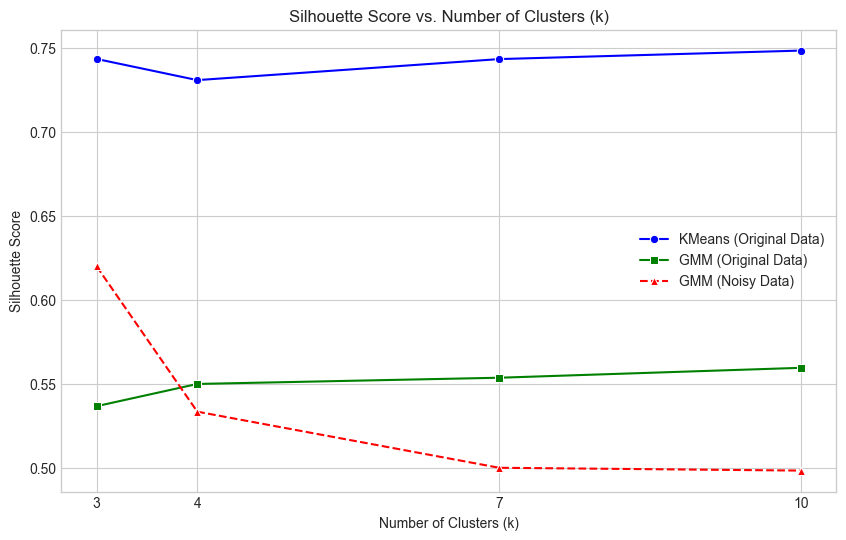

In [73]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=summary_df_sorted[summary_df_sorted['Algorithm'] == 'KMeans'],
             x='k', y='Silhouette', marker='o', label='KMeans (Original Data)', color='blue')
sns.lineplot(data=summary_df_sorted[(summary_df_sorted['Algorithm'] == 'GMM') & (summary_df_sorted['Noise_Status'] == 'Original')],
             x='k', y='Silhouette', marker='s', label='GMM (Original Data)', color='green')
sns.lineplot(data=summary_df_sorted[(summary_df_sorted['Algorithm'] == 'GMM') & (summary_df_sorted['Noise_Status'] == 'Noisy')],
             x='k', y='Silhouette', marker='^', label='GMM (Noisy Data)', color='red', linestyle='--')

plt.title('Silhouette Score vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(summary_df_sorted['k'].unique())
plt.grid(True)
plt.legend()
plt.show()

In [74]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import pandas as pd # Ensure pandas is imported if not already

# 1. Filter: Keep only Corporate RUCs (Starting with 20)
# We also handle that '0' RUC if it's a data noise entry
segmentation_data_corp = segmentation_data[
    (segmentation_data.index.astype(str).str.startswith('20'))
].copy()

# 2. RE-SCALE: Crucial because the distribution of 'Total_Spend' has changed
features = ['Total_Spend', 'Product_Variety', 'Years_Active', 'Transaction_Count']
scaler = StandardScaler()
scaled_features_corp = scaler.fit_transform(segmentation_data_corp[features])

# 3. Fit GMM with 10 components (as per your promoter's advice)
# Reference: Unknown-21.png shows n=10 is a stable re-dip in scores
gmm_k10 = GaussianMixture(n_components=10, covariance_type='full', random_state=42)
gmm_labels_k10 = gmm_k10.fit_predict(scaled_features_corp)
probs_k10 = gmm_k10.predict_proba(scaled_features_corp)

# 4. Integrate Results
segmentation_data_corp['GMM_Cluster_k10'] = gmm_labels_k10

# Add all 10 probabilities (Soft Clustering)
for i in range(10):
    segmentation_data_corp[f'Prob_Cluster_k10_{i}'] = probs_k10[:, i]

print(f"B2B GMM Complete (k=10). {len(segmentation_data_corp)} Corporate Entities Analyzed.")
display(segmentation_data_corp.sort_values('Total_Spend', ascending=False).head(10))

print("--- Top Importers in Each GMM Cluster (Corporate Data, k=10) ---")

top_importers_k10_dict = {}
for cluster_id in sorted(segmentation_data_corp['GMM_Cluster_k10'].unique()):
    cluster_importers = segmentation_data_corp[segmentation_data_corp['GMM_Cluster_k10'] == cluster_id].copy()
    cluster_importers['COMPANY_NAME'] = cluster_importers.index.map(name_map)

    # Filter out any potential non-company names if name_map has them (e.g., "PROTECCION")
    noise_keywords = 'BANCO|BANK|LEASING|CREDITO|FINANCI|PROTECCION|PERSONALES|SEGURIDAD'
    clean_importers = cluster_importers[
        (cluster_importers['COMPANY_NAME'].notna()) &
        (~cluster_importers['COMPANY_NAME'].str.contains(noise_keywords, case=False, na=False))
    ]

    top_importers = clean_importers.sort_values('Total_Spend', ascending=False).head(10)

    if not top_importers.empty:
        print(f"\nCluster {cluster_id}:")
        display(top_importers[['COMPANY_NAME', 'Total_Spend', 'Product_Variety', 'Years_Active', 'Transaction_Count']])
        top_importers_k10_dict[f'Cluster_{cluster_id}'] = top_importers[['COMPANY_NAME', 'Total_Spend', 'Product_Variety', 'Years_Active', 'Transaction_Count']]
    else:
        print(f"\nCluster {cluster_id}: No identifiable top importers.")

# Save k=10 results to Excel
output_filename_k10 = 'GMM_Corporate_Clusters_k10.xlsx'
with pd.ExcelWriter(output_filename_k10) as writer:
    for cluster_name, df in top_importers_k10_dict.items():
        df.to_excel(writer, sheet_name=cluster_name, index=True)
print(f"\nTop importers for k=10 clusters saved to {output_filename_k10}")


# --- GMM Clustering with k=7 for Corporate Entities ---
print("\n--- Running GMM Clustering with k=7 for Corporate Entities ---")

# 1. Filter: Keep only Corporate RUCs (Starting with 20)
# (This DataFrame is already created as segmentation_data_corp above)

# 2. RE-SCALE: Crucial because the distribution of 'Total_Spend' has changed
# (scaled_features_corp is already computed above)

# 3. Fit GMM with 7 components
gmm_k7 = GaussianMixture(n_components=7, covariance_type='full', random_state=42)
gmm_labels_k7 = gmm_k7.fit_predict(scaled_features_corp)
probs_k7 = gmm_k7.predict_proba(scaled_features_corp)

# 4. Integrate Results into a new column
segmentation_data_corp['GMM_Cluster_k7'] = gmm_labels_k7

# Add all 7 probabilities (Soft Clustering)
for i in range(7):
    segmentation_data_corp[f'Prob_Cluster_k7_{i}'] = probs_k7[:, i]

print(f"B2B GMM Complete (k=7). {len(segmentation_data_corp)} Corporate Entities Analyzed.")
display(segmentation_data_corp.sort_values('Total_Spend', ascending=False).head(10))

print("--- Top Importers in Each GMM Cluster (Corporate Data, k=7) ---")

top_importers_k7_dict = {}
for cluster_id in sorted(segmentation_data_corp['GMM_Cluster_k7'].unique()):
    cluster_importers = segmentation_data_corp[segmentation_data_corp['GMM_Cluster_k7'] == cluster_id].copy()
    cluster_importers['COMPANY_NAME'] = cluster_importers.index.map(name_map)

    # Filter out any potential non-company names if name_map has them (e.g., "PROTECCION")
    noise_keywords = 'BANCO|BANK|LEASING|CREDITO|FINANCI|PROTECCION|PERSONALES|SEGURIDAD'
    clean_importers = cluster_importers[
        (cluster_importers['COMPANY_NAME'].notna()) &
        (~cluster_importers['COMPANY_NAME'].str.contains(noise_keywords, case=False, na=False))
    ]

    top_importers = clean_importers.sort_values('Total_Spend', ascending=False).head(10)

    if not top_importers.empty:
        print(f"\nCluster {cluster_id}:")
        display(top_importers[['COMPANY_NAME', 'Total_Spend', 'Product_Variety', 'Years_Active', 'Transaction_Count']])
        top_importers_k7_dict[f'Cluster_{cluster_id}'] = top_importers[['COMPANY_NAME', 'Total_Spend', 'Product_Variety', 'Years_Active', 'Transaction_Count']]
    else:
        print(f"\nCluster {cluster_id}: No identifiable top importers.")

# Save k=7 results to Excel
output_filename_k7 = 'GMM_Corporate_Clusters_k7.xlsx'
with pd.ExcelWriter(output_filename_k7) as writer:
    for cluster_name, df in top_importers_k7_dict.items():
        df.to_excel(writer, sheet_name=cluster_name, index=True)
print(f"\nTop importers for k=7 clusters saved to {output_filename_k7}")

B2B GMM Complete (k=10). 1410 Corporate Entities Analyzed.


,Total_Spend,Product_Variety,Years_Active,Transaction_Count,Cluster,GMM_Cluster_k10,Prob_Cluster_k10_0,Prob_Cluster_k10_1,Prob_Cluster_k10_2,Prob_Cluster_k10_3,Prob_Cluster_k10_4,Prob_Cluster_k10_5,Prob_Cluster_k10_6,Prob_Cluster_k10_7,Prob_Cluster_k10_8,Prob_Cluster_k10_9
RUC IMPORTADOR,,,,,,,,,,,,,,,,
20538234754,"51,342,940.90",4,11,837,5,2,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
20100028698,"38,112,101.08",6,8,180,6,8,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
20170072465,"23,375,503.01",3,10,4,7,4,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
20448664717,"11,206,072.32",4,11,154,7,7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
20517931536,"10,347,040.79",8,11,198,3,7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
20537984032,"10,076,569.89",5,11,207,7,7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
20487799484,"9,789,632.48",3,5,103,7,7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
20606433469,"7,876,555.80",6,6,154,3,7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
20601770815,"7,689,277.56",7,9,123,3,3,0.00,0.00,0.00,0.98,0.00,0.00,0.00,0.02,0.00,0.00


--- Top Importers in Each GMM Cluster (Corporate Data, k=10) ---

Cluster 0:


,COMPANY_NAME,Total_Spend,Product_Variety,Years_Active,Transaction_Count
RUC IMPORTADOR,,,,,
20544913523,COMECO MAQUINARIA Y REPRESENTACIONES SAC,"289,436.29",1,0,1
20392965191,CONCRETOS SUPERMIX SOCIEDAD ANONIMA - CONCRETO...,"285,718.12",1,0,1
20524670128,YUNKAMAYO CONTRATISTAS GENERALES S.A.C.,"276,657.16",1,0,1
20437481653,SERVI-SAP SRL,"254,891.00",1,0,1
20610227466,CASA AL TOKE S.A.C.,"250,400.00",1,0,2
20506285314,COMPAÑIA MINERA MISKI MAYO S.R.L.,"249,347.00",1,0,1
20611812231,TUPAC CORPORATION E.I.R.L.,"247,534.68",1,0,3
20450583953,FATSUR E.I.R.L.,"233,700.00",1,0,2
20601148901,GOOD EARTH DRILLING INTERNATIONAL SOCIEDAD ANO...,"232,100.00",1,0,1



Cluster 1:


...


Cluster 5:


,COMPANY_NAME,Total_Spend,Product_Variety,Years_Active,Transaction_Count
RUC IMPORTADOR,,,,,
20546121250,STRACON GYM S.A.,"3,615,694.24",3,7,8
20100027021,UNIMAQ S.A.,"3,420,496.98",1,7,37
20605310525,DISTRIBUCIONES JESAN EMPRESA INDIVIDUAL DE RES...,"3,206,428.32",2,6,42
20479870595,CERAMICOS DEL NORTE EIRL,"2,890,951.42",3,8,42
20418826119,MAS ERRAZURIZ DEL PERU S.A.C.,"2,889,362.42",2,4,7
20448547087,VERA GOLD E.I.R.L.,"2,814,987.85",2,10,38
20209133394,MINERA BARRICK MISQUICHILCA SA,"2,698,328.42",2,0,3
20254813720,CHAVIN DE HUANTAR E.I.R.L,"2,692,125.58",6,9,39
20603941285,BEIJING SHOUGANG MINE CONSTRUCTION ENGINEERING...,"2,634,750.00",2,0,5



Cluster 6:


,COMPANY_NAME,Total_Spend,Product_Variety,Years_Active,Transaction_Count
RUC IMPORTADOR,,,,,
20605418661,KORY K Y B SOCIEDAD COMERCIAL DE RESPONSABILID...,"291,685.72",2,1,4
20447819211,MMC INGENIERIA Y NEGOCIOS SOCIEDAD ANONIMA CER...,"283,200.00",1,1,3
20516570122,DEMOLICIONES CACEDA MENDOZA SAC,"281,115.00",1,2,3
20519813751,JUAN CARLOS MAMANI INVERSIONES S.C.R.L.,"265,291.59",2,1,4
20604728054,PICHARI MOTORS S.R.L.,"265,100.00",1,1,3
20610083910,BEMVEN CORPORATION SOCIEDAD ANÓNIMA CERRADA,"259,082.77",1,0,5
20601206022,PAVIMENTOS Y CONSTRUCCION JORDAN S.A.C.,"257,167.20",1,2,2
20506662711,LUPPAARCONTRATISTASGENERALESSRL,"251,932.94",1,1,4
20542052792,"EMPRESA CONSULTORA, CONSTRUCT. Y DE TRANSP. SE...","251,000.00",1,2,5



Top importers for k=7 clusters saved to GMM_Corporate_Clusters_k7.xlsx


In [75]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# 1. Filter: Keep only Corporate RUCs (Starting with 20)
# We also handle that '0' RUC if it's a data noise entry
segmentation_data_corp = segmentation_data[
    (segmentation_data.index.astype(str).str.startswith('20'))
].copy()

# 2. RE-SCALE: Crucial because the distribution of 'Total_Spend' has changed
features = ['Total_Spend', 'Product_Variety', 'Years_Active', 'Transaction_Count']
scaler = StandardScaler()
scaled_features_corp = scaler.fit_transform(segmentation_data_corp[features])

# 3. Fit GMM with 10 components (as per your promoter's advice)
# Reference: Unknown-21.png shows n=10 is a stable re-dip in scores
gmm = GaussianMixture(n_components=10, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(scaled_features_corp)
probs = gmm.predict_proba(scaled_features_corp)

# 4. Integrate Results
segmentation_data_corp['GMM_Cluster'] = gmm_labels

# Add all 10 probabilities (Soft Clustering)
for i in range(10):
    segmentation_data_corp[f'Prob_Cluster_{i}'] = probs[:, i]

print(f"B2B GMM Complete. {len(segmentation_data_corp)} Corporate Entities Analyzed.")
display(segmentation_data_corp.sort_values('Total_Spend', ascending=False).head(10))

B2B GMM Complete. 1410 Corporate Entities Analyzed.


,Total_Spend,Product_Variety,Years_Active,Transaction_Count,Cluster,GMM_Cluster,Prob_Cluster_0,Prob_Cluster_1,Prob_Cluster_2,Prob_Cluster_3,Prob_Cluster_4,Prob_Cluster_5,Prob_Cluster_6,Prob_Cluster_7,Prob_Cluster_8,Prob_Cluster_9
RUC IMPORTADOR,,,,,,,,,,,,,,,,
20538234754,"51,342,940.90",4,11,837,5,2,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
20100028698,"38,112,101.08",6,8,180,6,8,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
20170072465,"23,375,503.01",3,10,4,7,4,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
20448664717,"11,206,072.32",4,11,154,7,7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
20517931536,"10,347,040.79",8,11,198,3,7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
20537984032,"10,076,569.89",5,11,207,7,7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
20487799484,"9,789,632.48",3,5,103,7,7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
20606433469,"7,876,555.80",6,6,154,3,7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
20601770815,"7,689,277.56",7,9,123,3,3,0.00,0.00,0.00,0.98,0.00,0.00,0.00,0.02,0.00,0.00


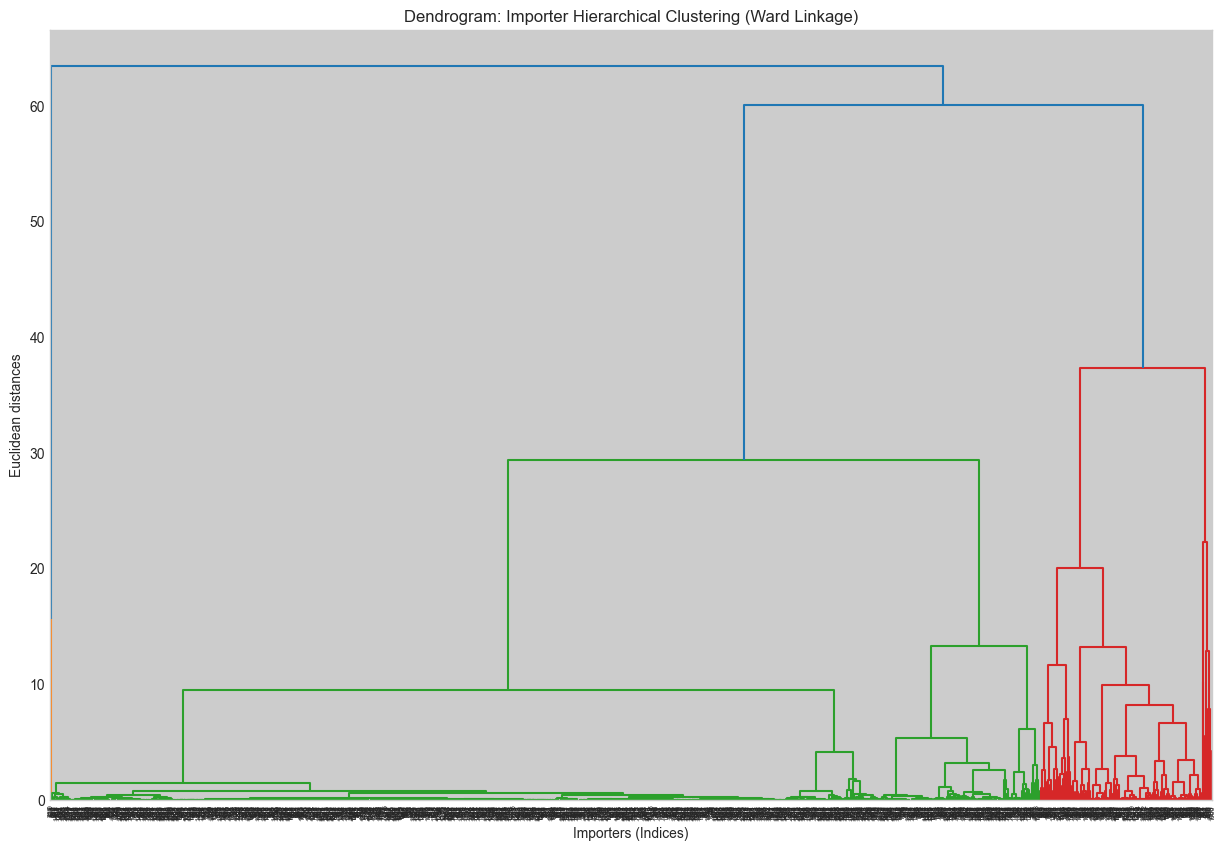

--- Cophenetic Correlation Coefficient Comparison ---
Ward Linkage: 0.6163
Single Linkage: 0.9025
Complete Linkage: 0.9388


In [76]:
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

# Define linkage methods to compare
linkage_methods = ['ward', 'single', 'complete']
cophenetic_results = {}

plt.figure(figsize=(15, 10))

for i, method in enumerate(linkage_methods):
    # Calculate the linkage matrix
    linkage_matrix = sch.linkage(scaled_features, method=method)

    # Calculate the Cophenetic Correlation Coefficient
    c, coph_dists = cophenet(linkage_matrix, pdist(scaled_features))
    cophenetic_results[method] = c

    # Plot dendrogram for each (optional, can be very large for many methods)
    # For this comparison, let's just show 'ward' and print results
    if method == 'ward': # Only plot the 'ward' dendrogram for brevity
        plt.title(f'Dendrogram: Importer Hierarchical Clustering ({method.capitalize()} Linkage)')
        dendrogram = sch.dendrogram(linkage_matrix)
        plt.xlabel('Importers (Indices)')
        plt.ylabel('Euclidean distances')

plt.show()

print("--- Cophenetic Correlation Coefficient Comparison ---")
for method, coeff in cophenetic_results.items():
    print(f"{method.capitalize()} Linkage: {coeff:.4f}")

In [77]:
from sklearn.cluster import AgglomerativeClustering

# 1. Perform the 'Cut' on the Dendrogram at 4 clusters
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
segmentation_data['HC_Cluster'] = hc.fit_predict(scaled_features)

# 2. Identify which cluster your best clients belong to
# Example: Let's find where KARLA EQUIPMENT (RUC 20517931536) sits
client_rucs = ['20517931536', '20490425668', '20602250866'] # Karla, Kalicanto, FC
client_segments = segmentation_data.loc[segmentation_data.index.isin(client_rucs), 'HC_Cluster']

print("--- Current Client Segment Mapping ---")
print(client_segments)

# 3. Find the "Prospects" (Companies in the same branch that aren't your clients yet)
for cluster_id in client_segments.unique():
    prospects = segmentation_data[
        (segmentation_data['HC_Cluster'] == cluster_id) &
        (~segmentation_data.index.isin(client_rucs))
    ].sort_values('Total_Spend', ascending=False).head(10)

    print(f"\n--- Top 10 Prospects in Cluster {cluster_id} (Similar to your best clients) ---")
    # Mapping RUC to Name for the final list
    prospects['Name'] = prospects.index.map(name_map)
    display(prospects[['Name', 'Total_Spend', 'Transaction_Count']])

--- Current Client Segment Mapping ---
RUC IMPORTADOR
20490425668    2
20517931536    2
20602250866    2
Name: HC_Cluster, dtype: int64

--- Top 10 Prospects in Cluster 2 (Similar to your best clients) ---


,Name,Total_Spend,Transaction_Count
RUC IMPORTADOR,,,
20100028698,FERREYROS SOCIEDAD AN?NIMA,"38,112,101.08",180
20170072465,SOCIEDAD MINERA CERRO VERDE S.A.A.,"23,375,503.01",4
20448664717,GH EQUIPMENT E.I.R.L.,"11,206,072.32",154
20537984032,DESERT LOGISTIC SERVICES S.A.C.,"10,076,569.89",207
20606433469,ECA BUSINESS E.I.R.L.,"7,876,555.80",154
20601770815,DAMICON BUSINESS S.A.C.,"7,689,277.56",123
20546301312,SICIMSPASUCURSALDELPERU,"6,379,835.49",38
20518118103,TOTAL CAMIONETAS S.A.C.,"6,038,862.61",151
20501417646,TRANSPORTES GEMAR E.I.R.L.,"5,698,069.47",140


### Feature Distributions Across Hierarchical Clusters

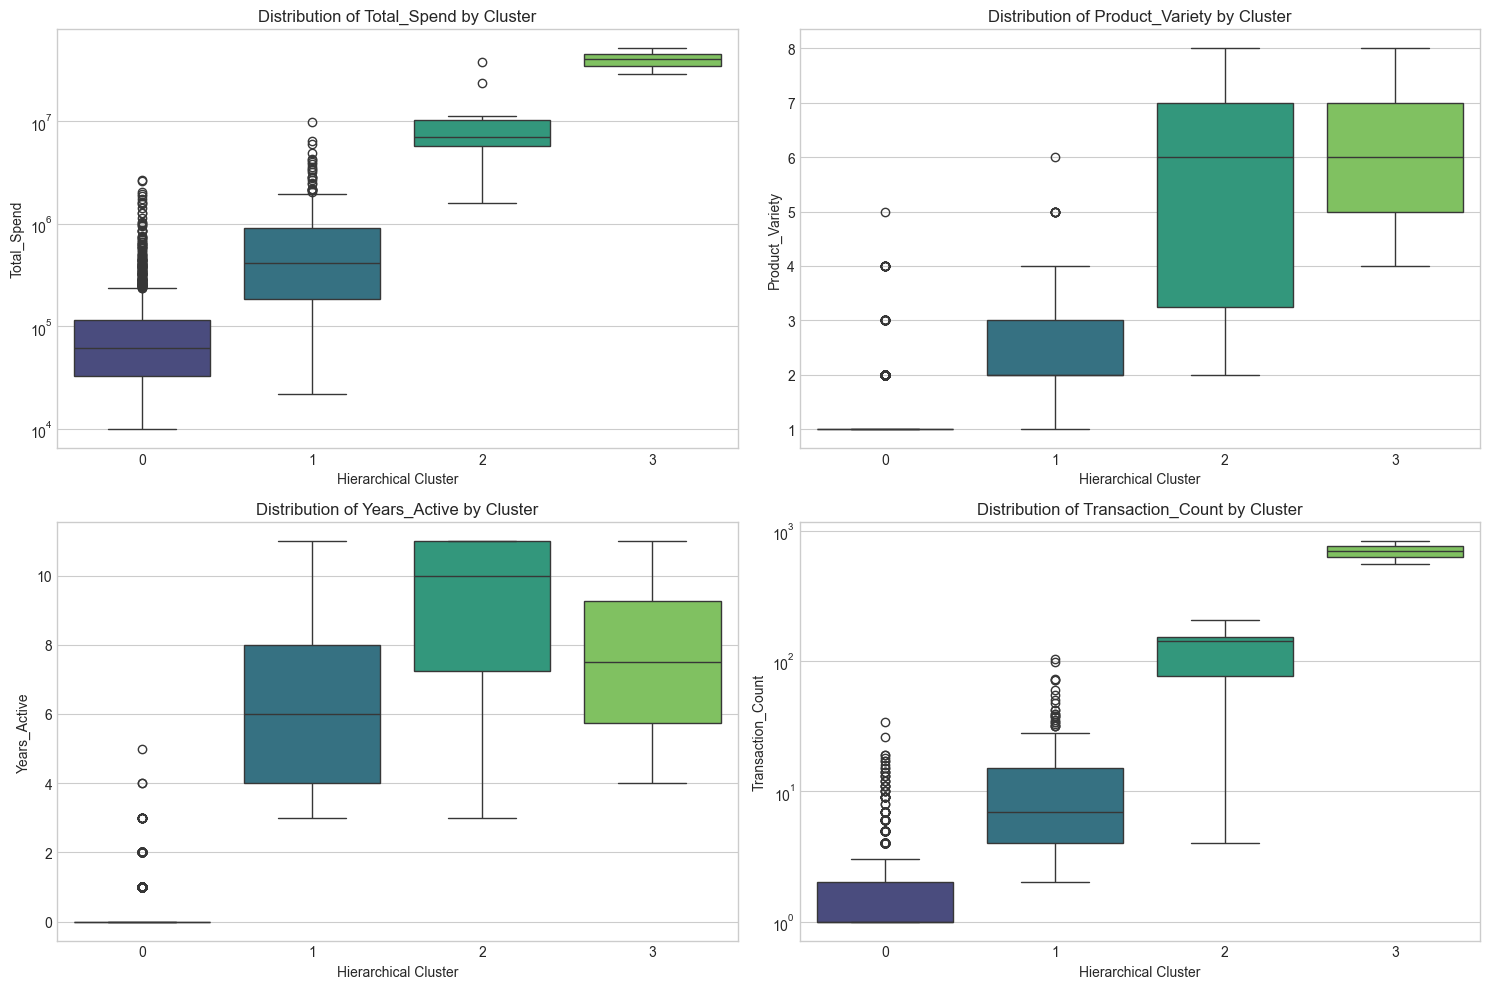

In [78]:
from sklearn.cluster import AgglomerativeClustering

features_to_plot = ['Total_Spend', 'Product_Variety', 'Years_Active', 'Transaction_Count']

# Ensure HC_Cluster is in segmentation_data immediately before plotting
# Re-run the AgglomerativeClustering to ensure the column is present and up-to-date
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
segmentation_data['HC_Cluster'] = hc.fit_predict(scaled_features)

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.boxplot(data=segmentation_data, x='HC_Cluster', y=feature, palette='viridis')
    plt.title(f'Distribution of {feature} by Cluster')
    plt.xlabel('Hierarchical Cluster')
    plt.ylabel(feature)

    # Apply log scale for highly skewed features like Total_Spend and Transaction_Count
    if feature in ['Total_Spend', 'Transaction_Count']:
        plt.yscale('log')

plt.tight_layout()
plt.show()

In [79]:
print("--- Clustering Algorithms Metrics Comparison ---")

print("\n--- K-Means & GMM Metrics (Original and Noisy Data) ---")
# Display the combined summary DataFrame for KMeans and GMM
display(summary_df_sorted)

print("\n--- K-Means PWI Results ---")
# Display PWI results for KMeans from the combined summary
display(summary_df_sorted[summary_df_sorted['Algorithm'] == 'KMeans'][['k', 'PWI']])

print("\n--- Hierarchical Clustering (Cophenetic Correlation Coefficient) ---")
# Display the Cophenetic Correlation Coefficient for hierarchical clustering
for method, coeff in cophenetic_results.items():
    print(f"  - {method.capitalize()} Linkage: {coeff:.4f}")

print("\nInterpretation:")
print("  - **Silhouette Score:** A higher score indicates better-defined clusters. KMeans generally shows slightly higher scores on original data.")
print("  - **Calinski-Harabasz Index:** Higher values indicate better-defined clusters. Similar trends to Silhouette.")
print("  - **Davies-Bouldin Index:** Lower values indicate better clustering. KMeans generally outperforms GMM on this metric for original data.")
print("  - **S_Dbw Index:** Lower values indicate better clustering (density and separation). GMM tends to achieve lower S_Dbw scores at higher k, indicating potentially better internal structure for those partitions.")
print("  - **PWI (Peak Weight Index):** A higher score indicates a better overall clustering solution, considering both cohesion and separation, with a focus on local optima. KMeans shows the highest PWI score at k=10.")
print("  - **Impact of Noise on GMM:** The metrics for GMM with noisy data generally show a decrease in quality (lower Silhouette/Calinski, higher Davies-Bouldin/S_Dbw), as expected.")
print("  - **Cophenetic Correlation Coefficient (Hierarchical):** Closer to 1 indicates a better fit of the dendrogram to the original data. 'Single' and 'Complete' linkages show high coefficients, suggesting good preservation of pairwise distances in the dendrogram, while 'Ward' is lower.")

--- Clustering Algorithms Metrics Comparison ---

--- K-Means & GMM Metrics (Original and Noisy Data) ---


,Algorithm,k,Noise_Status,Silhouette,Calinski_Harabasz,Davies_Bouldin,S_Dbw,PWI
0,GMM,3.00,Noisy,0.62,"1,179.59",0.76,3.10,0.71
1,GMM,3.00,Original,0.54,920.87,0.82,3.02,0.61
2,KMeans,3.00,Original,0.74,"1,453.10",0.67,3.22,0.26
3,GMM,4.00,Noisy,0.53,947.76,0.96,2.11,0.56
4,GMM,4.00,Original,0.55,862.55,1.14,2.41,0.58
5,KMeans,4.00,Original,0.73,"1,439.12",0.80,2.68,0.38
6,GMM,7.00,Noisy,0.50,"1,032.11",1.20,1.66,0.16
7,GMM,7.00,Original,0.55,692.93,2.37,1.66,0.56
8,KMeans,7.00,Original,0.74,"1,635.34",0.77,1.21,0.69
9,GMM,10.00,Noisy,0.50,985.20,0.96,0.82,0.15



--- K-Means PWI Results ---


,k,PWI
2,3.00,0.26
5,4.00,0.38
8,7.00,0.69
11,10.00,0.91



--- Hierarchical Clustering (Cophenetic Correlation Coefficient) ---
  - Ward Linkage: 0.6163
  - Single Linkage: 0.9025
  - Complete Linkage: 0.9388

Interpretation:
  - **Silhouette Score:** A higher score indicates better-defined clusters. KMeans generally shows slightly higher scores on original data.
  - **Calinski-Harabasz Index:** Higher values indicate better-defined clusters. Similar trends to Silhouette.
  - **Davies-Bouldin Index:** Lower values indicate better clustering. KMeans generally outperforms GMM on this metric for original data.
  - **S_Dbw Index:** Lower values indicate better clustering (density and separation). GMM tends to achieve lower S_Dbw scores at higher k, indicating potentially better internal structure for those partitions.
  - **PWI (Peak Weight Index):** A higher score indicates a better overall clustering solution, considering both cohesion and separation, with a focus on local optima. KMeans shows the highest PWI score at k=10.
  - **Impact of Nois

In [80]:
# ── Handoff: save clustering outputs for the market basket analysis notebook ──
import pickle, os

_handoff = {
    # From EDA handoff (pass-through)
    'df_units':         df_units,
    'df_used_market':   df_used_market,
    'name_map':         name_map,
    # Built in this notebook
    'segmentation_data': segmentation_data,   # importer-level RFM + cluster labels
    'scaled_features':   scaled_features,     # StandardScaler output
    'scaler':            scaler,               # fitted scaler (for inverse_transform)
}
_handoff_path = 'clustering_handoff.pkl'
with open(_handoff_path, 'wb') as _f:
    pickle.dump(_handoff, _f)
print(f'Saved handoff → {os.path.abspath(_handoff_path)}')
print(f'  df_units:          {df_units.shape}')
print(f'  df_used_market:    {df_used_market.shape}')
print(f'  segmentation_data: {segmentation_data.shape}')
print(f'  name_map keys:     {len(name_map)}')


Saved handoff → /Users/fabriziocontreras/Desktop/KUL/Masters/Thesis/code/clustering_handoff.pkl
  df_units:          (8599, 38)
  df_used_market:    (10239, 37)
  segmentation_data: (1586, 6)
  name_map keys:     4234
